In [12]:
import pandas as pd
import numpy as np
from collections import Counter

In [16]:
expensive_set = pd.read_csv('expensiveset.csv')
unreasonable_set = pd.read_csv('unreasonableset.csv')

In [18]:

# Load the two datasets
expensive_df = pd.read_csv('expensiveset.csv')
unreasonable_df = pd.read_csv('unreasonableset.csv')

# Perform an inner join on the specified columns
merged_df = pd.merge(expensive_df, unreasonable_df, 
                     on=['DISTRICT', 'NEXT DISTRICT'], 
                     how='inner')

# Save the merged result to a new CSV file
merged_df.to_csv('merged_results.csv', index=False)

print("Merged results have been saved to merged_results.csv")

Merged results have been saved to merged_results.csv


In [19]:
areas_to_districts = {
    "Kwai Tsing": ["Tsing Yi", "Kwai Chung East", "Kwai Chung West"],
    "North": ["Wu Tip Shan", "Robin's Nest"],
    "Sai Kung": ["Sai Kung and Hang Hau", "Tseung Kwan O South", "Tseung Kwan O North", "Hang Hau"],
    "Sha Tin": ['Sha Tin West', 'Sha Tin East', 'Sha Tin South', 'Sha Tin North'],
    "Tai Po": ['Tai Po South', 'Tai Po North'],
    "Tsuen Wan": ['Tsuen Wan Northwest', 'Tsuen Wan Southeast'],
    "Tuen Mun": ['Tuen Mun East', 'Tuen Mun West', 'Tuen Mun North'],
    "Yuen Long": ['Yuen Long Town Centre', 'Yuen Long Rural East', 'Tin Shui Wai South and Ping Ha'],
    "Kowloon City": ['Kowloon City North', 'Kowloon City South'],
    "Kwun Tong": ['Kwun Tong Southeast', 'Kwun Tong Central', 'Kwun Tong North', 'Kwun Tong West'],
    "Sham Shui Po": ['Sham Shui Po West', 'Sham Shui Po East'],
    "Wong Tai Sin": ['Wong Tai Sin East', 'Wong Tai Sin West'],
    "Yau Tsim Mong": ['Yau Tsim Mong South', 'Yau Tsim Mong North'],
    "Central and Western": ['Central', 'Western'],
    "Eastern": ['Tai Pak', 'Hong Wan', 'Chai Wan'],
    "Southern": ['Southern District Southeast', 'Southern District Northwest'],
    "Wan Chai": ['Wan Chai'],
    "Islands": ['Islands']
}

start_count = Counter(merged_df["DISTRICT"])
end_count = Counter(merged_df["NEXT DISTRICT"])

con_count = {}
for con in list(start_count.keys()) + list(end_count.keys()):
    con_count[con] = {
        "as_start": 0,
        "as_end": 0,
        "sum": 0
    }
    con_count[con]["as_start"] += start_count[con]
    con_count[con]["as_end"] += end_count[con]
    con_count[con]["sum"] += start_count[con] + end_count[con]

for k, v in con_count.items():
    print(f"{k:<40}: {v['as_start']:<3} start, {v['as_end']:<3} end, {v['sum']:<3} sum")

Central                                 : 1   start, 6   end, 7   sum
Islands                                 : 6   start, 14  end, 20  sum
Kowloon City North                      : 1   start, 1   end, 2   sum
Kowloon City South                      : 1   start, 0   end, 1   sum
Kwai Chung East                         : 1   start, 0   end, 1   sum
Kwai Chung West                         : 2   start, 0   end, 2   sum
Kwun Tong Central                       : 1   start, 2   end, 3   sum
Kwun Tong North                         : 2   start, 4   end, 6   sum
Wu Tip Shan                             : 2   start, 2   end, 4   sum
Sha Tin East                            : 2   start, 2   end, 4   sum
Sha Tin South                           : 2   start, 3   end, 5   sum
Sha Tin West                            : 2   start, 2   end, 4   sum
Sham Shui Po East                       : 1   start, 1   end, 2   sum
Sham Shui Po West                       : 1   start, 0   end, 1   sum
Southern District No

In [20]:
district_count = {}

for k, v in areas_to_districts.items():
    district_count[k] = {
        "as_start": 0,
        "as_end": 0,
        "sum": 0
    }
    for area in v:
        district_count[k]["as_start"] += start_count[area]
        district_count[k]["as_end"] += end_count[area]
        district_count[k]["sum"] += start_count[area] + end_count[area]
print(district_count)


for k, v in district_count.items():
    print(f"{k:<20}: {v['as_start']:<3} start, {v['as_end']:<3} end, {v['sum']:<3} sum")

{'Kwai Tsing': {'as_start': 3, 'as_end': 2, 'sum': 5}, 'North': {'as_start': 2, 'as_end': 2, 'sum': 4}, 'Sai Kung': {'as_start': 0, 'as_end': 2, 'sum': 2}, 'Sha Tin': {'as_start': 6, 'as_end': 8, 'sum': 14}, 'Tai Po': {'as_start': 5, 'as_end': 2, 'sum': 7}, 'Tsuen Wan': {'as_start': 7, 'as_end': 6, 'sum': 13}, 'Tuen Mun': {'as_start': 25, 'as_end': 6, 'sum': 31}, 'Yuen Long': {'as_start': 8, 'as_end': 3, 'sum': 11}, 'Kowloon City': {'as_start': 2, 'as_end': 1, 'sum': 3}, 'Kwun Tong': {'as_start': 3, 'as_end': 9, 'sum': 12}, 'Sham Shui Po': {'as_start': 2, 'as_end': 1, 'sum': 3}, 'Wong Tai Sin': {'as_start': 1, 'as_end': 3, 'sum': 4}, 'Yau Tsim Mong': {'as_start': 3, 'as_end': 5, 'sum': 8}, 'Central and Western': {'as_start': 1, 'as_end': 6, 'sum': 7}, 'Eastern': {'as_start': 0, 'as_end': 0, 'sum': 0}, 'Southern': {'as_start': 3, 'as_end': 5, 'sum': 8}, 'Wan Chai': {'as_start': 2, 'as_end': 4, 'sum': 6}, 'Islands': {'as_start': 6, 'as_end': 14, 'sum': 20}}
Kwai Tsing          : 3   star

In [21]:
import csv

# Specify the output CSV file name
output_file = 'district_count.csv'
s = 0
# Write the district_count dictionary to a CSV file
with open(output_file, mode='w', newline='') as file:
    writer = csv.writer(file)
    # Write the header
    writer.writerow(['District', 'As Start', 'As End', 'Sum'])
    # Write the data
    for district, counts in district_count.items():
        s += counts['sum']
        writer.writerow([district, counts['as_start'], counts['as_end'], counts['sum']])
print(s)
print(f"District counts have been saved to {output_file}")

158
District counts have been saved to district_count.csv


In [22]:
import csv

# Specify the output CSV file name
output_file = 'constituency_count.csv'
s = 0
# Write the district_count dictionary to a CSV file
with open(output_file, mode='w', newline='') as file:
    writer = csv.writer(file)
    # Write the header
    writer.writerow(['District', 'As Start', 'As End', 'Sum'])
    # Write the data
    for district, counts in con_count.items():
        s += counts['sum']
        writer.writerow([district, counts['as_start'], counts['as_end'], counts['sum']])
print(s)
print(f"District counts have been saved to {output_file}")

158
District counts have been saved to constituency_count.csv


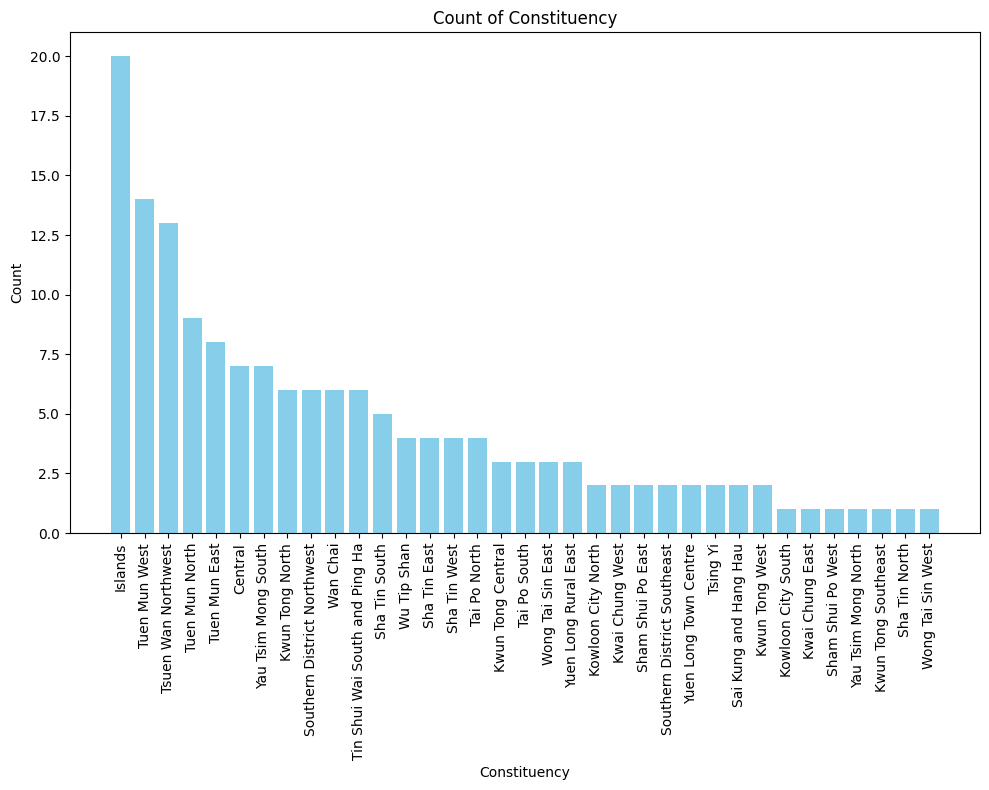

In [23]:
import matplotlib.pyplot as plt

# Sort con_count by the 'sum' value in descending order
sorted_con_count = sorted(con_count.items(), key=lambda x: x[1]['sum'], reverse=True)

# Extract the constituency names and their corresponding sums
constituencies = [item[0] for item in sorted_con_count]
sums = [item[1]['sum'] for item in sorted_con_count]

# Create a bar chart
plt.figure(figsize=(10, 8))
plt.bar(constituencies, sums, color='skyblue')
plt.xlabel('Constituency')
plt.ylabel('Count')
plt.title('Count of Constituency')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()